In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

fetch the data

In [3]:
diamonds = sns.load_dataset('diamonds')

In [5]:
diamonds.shape

(53940, 10)

Sample of data

In [7]:
df_sample = diamonds.sample(n=1000,random_state=42).copy()

Configure the canva

In [15]:
df_sample.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1388,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
50052,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
41645,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
42377,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
17244,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


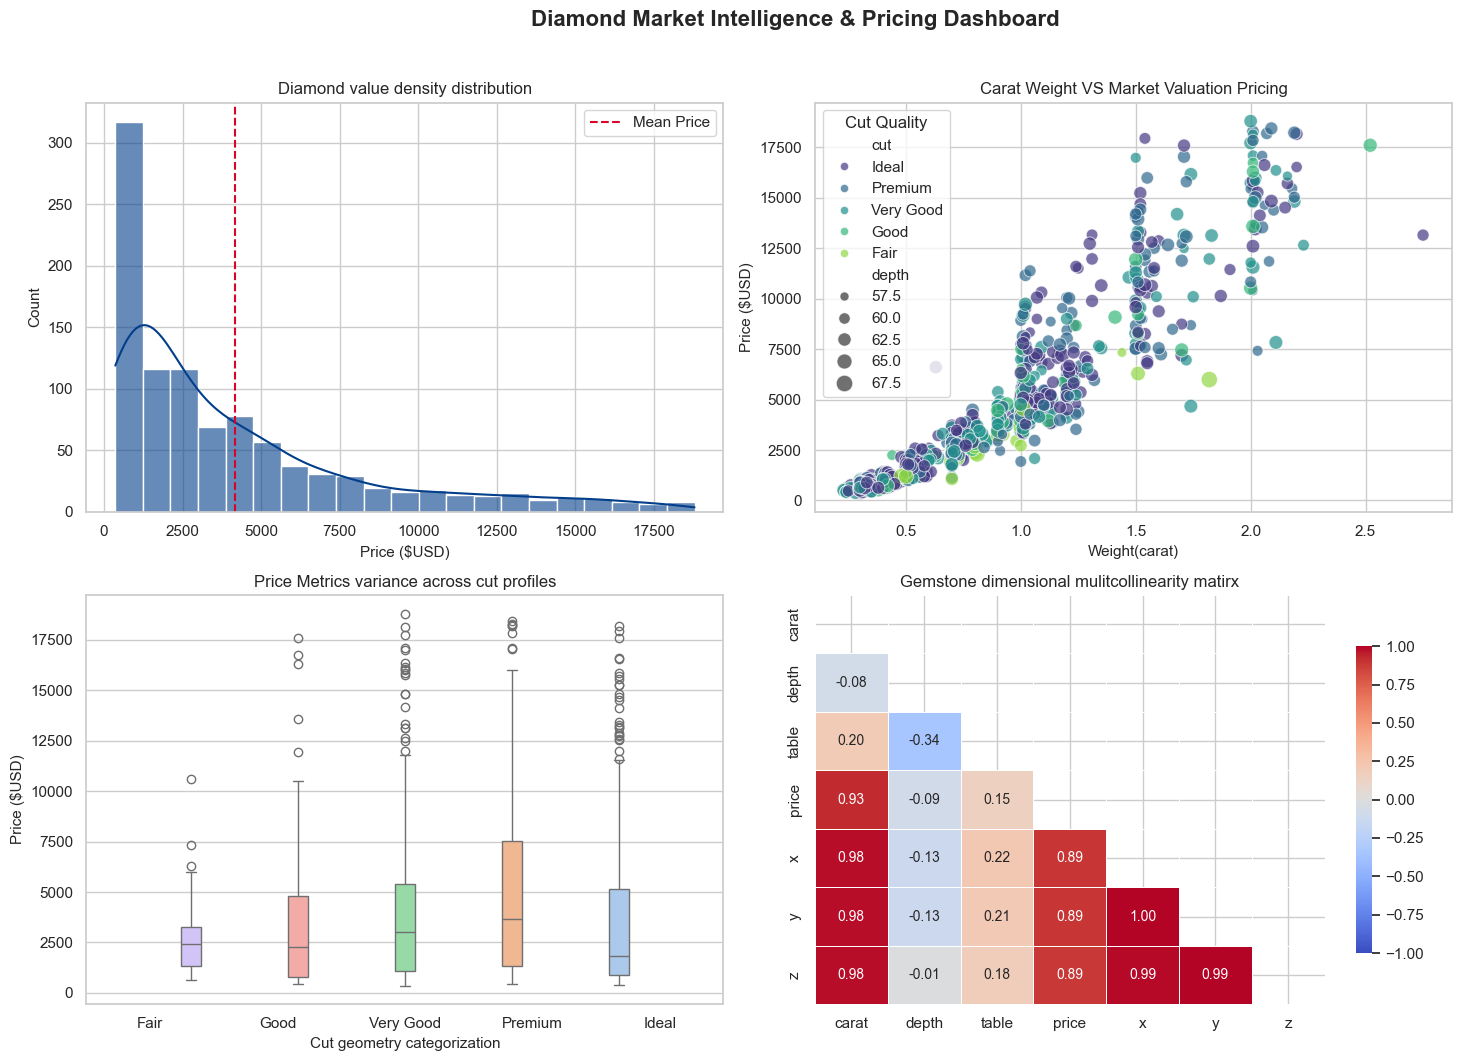

In [20]:
sns.set_theme(style='whitegrid',palette='muted')

plt.rcParams.update({
    'font.size':10,
    'axes.labelsize':11,
    'axes.titlesize':12,
    'figure.titlesize':16
})

fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(16,11))
fig.suptitle("Diamond Market Intelligence & Pricing Dashboard",fontweight='bold',y=0.96)

sns.histplot(data=df_sample,x='price',kde=True,color='#023E8A',ax=axes[0,0],alpha=0.6)
axes[0,0].axvline(df_sample['price'].mean(),color='#D90429',linestyle='--',linewidth=1.5,label='Mean Price')
axes[0,0].set_title("Diamond value density distribution")
axes[0,0].set_xlabel("Price ($USD)")
axes[0,0].legend()


sns.scatterplot(
    data=df_sample,x='carat',y='price',
    hue='cut',palette='viridis',alpha=0.7,edgecolor='w',
    size='depth',sizes=(20,150),ax=axes[0,1]
)
axes[0,1].set_title("Carat Weight VS Market Valuation Pricing")
axes[0,1].set_xlabel("Weight(carat)")
axes[0,1].set_ylabel("Price ($USD)")
axes[0,1].legend(title='Cut Quality',loc='upper left')


cut_order = ['Fair','Good','Very Good','Premium','Ideal']
sns.boxplot(
    data=df_sample,x='cut',y='price',
    order=cut_order,
    hue='cut',palette='pastel',
    ax=axes[1,0]
)
axes[1,0].set_title("Price Metrics variance across cut profiles")
axes[1,0].set_xlabel("Cut geometry categorization")
axes[1,0].set_ylabel("Price ($USD)")


numeric_cols = df_sample.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
mask = np.triu(np.ones_like(corr_matrix,dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,fmt='.2f',
    cmap='coolwarm',
    vmin=-1,vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.75},
    ax=axes[1,1]
)
axes[1,1].set_title('Gemstone dimensional mulitcollinearity matirx')

plt.tight_layout(rect=[0,0,0.92,0.94])

plt.show()
